# CentralGraphFormer for Lung Cancer CT Classification
**Adapted from:** *CentralGraphFormer: Center-Guided Spectral–Spatial Graph Transformer for Hyperspectral Image Classification*  
Zilin Zhang, Haoyang Yu, Zhaohui Jiang, Kangkang Li, Dong Pan, Weihua Gui — IEEE TGRS, Vol. 64, 2026

---
### Architecture → CT Adaptation Mapping
| Paper Component | HSI Role | CT Adaptation |
|---|---|---|
| **S³-Net** | Spectral shift separable network | Channel-shift separable conv on RGB/grayscale CT patches |
| **CBAM** | Lightweight channel+spatial attention refinement | Identical — channel attention on C, spatial on H×W |
| **SDG** | Stochastic Dynamic Gating (spatial relevance) | Cosine+Euclidean similarity to centre patch token |
| **BVB** | Biological Vision Blurring (Gaussian + radial decay) | Identical formulas, σ/σ_d tuned for 224×224 patches |
| **CGAM / CGAB** | Centre-guided sparse graph attention | Identical — centre pixel = centre token of patch grid |
| **MHGConv** | Multi-head graph convolution for graph-aware keys | Identical edge-MLP + degree-normalised aggregation |
| **Fusion head** | Concat multi-stage centre tokens → Linear | Identical (L=4 CGAB stages) |
| **Optimiser** | AdamW lr=1e-4, wd=1e-4 | Identical (paper setting) |
| **Scheduler** | ReduceLROnPlateau factor=0.1 | Identical (paper setting) |
| **Patch size** | 13×13 around centre pixel | 13×13 sliding patch over 224×224 CT images |

**Dataset:** IQ-OTH/NCCD — 3 classes: Normal, Benign, Malignant  
**Paper training:** AdamW, lr=1e-4, wd=1e-4, batch=32, 200 epochs, early stopping patience=20, AMP

## Cell 1 — Mount Drive & Verify Paths

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

DRIVE_TRAIN = '/content/drive/MyDrive/Lung Cancer/train'
DRIVE_TEST  = '/content/drive/MyDrive/Lung Cancer/test'

assert os.path.exists(DRIVE_TRAIN), f'Not found: {DRIVE_TRAIN}'
assert os.path.exists(DRIVE_TEST),  f'Not found: {DRIVE_TEST}'

# ── Canonical class names for IQ-OTH/NCCD ───────────────────────────────────
CANONICAL_CLASSES = ['benign', 'malignant', 'normal']
IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif'}

def folder_to_class(folder_name):
    """
    Maps any folder name variant → canonical class. Returns None for junk.
    Handles:
      'Bengin cases' / 'benign'        → 'benign'   (note: 'Bengin' is a typo)
      'Malignant cases' / 'malignant'  → 'malignant'
      'Normal cases' / 'normal'        → 'normal'
      'output' / 'train'               → None  (skipped)
    """
    fn = folder_name.lower().strip()
    if 'benign' in fn or 'bengin' in fn:
        return 'benign'
    if 'malignant' in fn:
        return 'malignant'
    if 'normal' in fn:
        return 'normal'
    return None

def scan_split(root, label):
    """
    Walk root, merge all variant folders into 3 canonical classes.
    Returns: {class_name: [abs_image_path, ...]}
    """
    mapping = {c: [] for c in CANONICAL_CLASSES}
    print(f'\n=== {label} ({root}) ===')
    for folder in sorted(os.listdir(root)):
        fpath = os.path.join(root, folder)
        if not os.path.isdir(fpath):
            continue
        cls = folder_to_class(folder)
        if cls is None:
            print(f'  [SKIP] {folder}')
            continue
        imgs = [
            os.path.join(fpath, f)
            for f in sorted(os.listdir(fpath))
            if os.path.splitext(f)[1].lower() in IMG_EXTS
        ]
        print(f'  {folder:<24} → {cls:<12} ({len(imgs)} images)')
        mapping[cls].extend(imgs)
    # Remove any duplicates (same file listed by two folders)
    for cls in CANONICAL_CLASSES:
        mapping[cls] = list(dict.fromkeys(mapping[cls]))
    print('  --- Canonical totals ---')
    for cls in CANONICAL_CLASSES:
        print(f'  {cls:<12}: {len(mapping[cls])}')
    return mapping

TRAIN_MAP = scan_split(DRIVE_TRAIN, 'TRAIN')
TEST_MAP  = scan_split(DRIVE_TEST,  'TEST')

for cls in CANONICAL_CLASSES:
    assert len(TRAIN_MAP[cls]) > 0, f'No train images for class: {cls}'
    assert len(TEST_MAP[cls])  > 0, f'No test images for class: {cls}'
print('\nAll 3 classes verified ✅')

Mounted at /content/drive

=== TRAIN (/content/drive/MyDrive/Lung Cancer/train) ===
  Bengin cases             → benign       (120 images)
  Malignant cases          → malignant    (569 images)
  Normal cases             → normal       (417 images)
  benign                   → benign       (5 images)
  malignant                → malignant    (5 images)
  normal                   → normal       (4 images)
  [SKIP] output
  [SKIP] train
  --- Canonical totals ---
  benign      : 125
  malignant   : 574
  normal      : 421

=== TEST (/content/drive/MyDrive/Lung Cancer/test) ===
  Bengin cases             → benign       (12 images)
  Malignant cases          → malignant    (113 images)
  Normal cases             → normal       (83 images)
  --- Canonical totals ---
  benign      : 12
  malignant   : 113
  normal      : 83

All 3 classes verified ✅


## Cell 2 — Install & Imports

In [2]:
!pip install timm -q

In [3]:
import math, shutil, time, warnings, random
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Paper hyperparameters (exact from Section IV-B) ──────────────────────────
LR           = 1e-4    # paper: AdamW lr=1e-4
WD           = 1e-4    # paper: weight_decay=1e-4
BATCH_SIZE   = 32      # paper: batch_size=32
EPOCHS       = 200     # paper: max 200 epochs
PATIENCE     = 40      # increased: 20 was too aggressive for small dataset
PATCH_SIZE   = 64      # increased: 13×13 is too small for 224×224 CT images
                       # 64×64 gives meaningful diagnostic context
NUM_HEADS    = 8       # paper: 8 heads
NUM_CGAB     = 4       # paper: L=4 stacked CGABs
SDG_T        = 5       # paper: T sampling rounds
SDG_M        = 0.6     # top-60% positions retained
SDG_ALPHA    = 0.5     # paper eq.(9): α
BVB_SIGMA    = 2.0     # increased for larger patch (was 1.0)
BVB_SIGMA_D  = 12.0    # increased for larger patch (was 3.0)
SCHED_FACTOR = 0.5     # less aggressive decay (paper=0.1 caused LR→1e-5 too fast)
SCHED_PAT    = 15      # scheduler patience (separate from early-stop patience)

# ── Dataset-specific ────────────────────────────────────────────────────────
IMG_SIZE     = 224
IN_CHANNELS  = 3
NUM_CLASSES  = 3

# ── S³-Net channel config ───────────────────────────────────────────────────
S3_GROUPS    = 4
S3_OUT_CH    = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU RAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
PyTorch: 2.11.0+cu128
GPU RAM: 15.6 GB


## Cell 3a — Copy Dataset to Local `/tmp`
Prevents `ConnectionAbortedError` from Drive FUSE when using `num_workers > 0`.

In [4]:
import shutil, time

LOCAL_TRAIN = '/tmp/LungCancer/train'
LOCAL_TEST  = '/tmp/LungCancer/test'

def copy_from_map(path_map, local_root, desc):
    """
    Copy files from TRAIN_MAP / TEST_MAP into a clean local folder tree.
    Structure: local_root/benign/, local_root/malignant/, local_root/normal/
    Skips files already present (idempotent).
    """
    already_done = all(
        os.path.isdir(os.path.join(local_root, cls))
        for cls in CANONICAL_CLASSES
    )
    if already_done:
        total = sum(
            len(os.listdir(os.path.join(local_root, cls)))
            for cls in CANONICAL_CLASSES
        )
        print(f'{desc}: already cached ({total} files) → {local_root}')
        return

    print(f'Copying {desc} → {local_root}  (one-time)...')
    t0 = time.time()
    total = 0
    for cls, paths in path_map.items():
        dst_dir = os.path.join(local_root, cls)
        os.makedirs(dst_dir, exist_ok=True)
        for src in paths:
            fname = os.path.basename(src)
            dst   = os.path.join(dst_dir, fname)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
            total += 1
    print(f'  Done in {time.time()-t0:.0f}s — {total} files')

copy_from_map(TRAIN_MAP, LOCAL_TRAIN, 'train')
copy_from_map(TEST_MAP,  LOCAL_TEST,  'test')

# Verify
print('\nLocal structure:')
for cls in CANONICAL_CLASSES:
    nt = len(os.listdir(os.path.join(LOCAL_TRAIN, cls)))
    nv = len(os.listdir(os.path.join(LOCAL_TEST,  cls)))
    print(f'  {cls:<12}  train={nt:>4}  test={nv:>4}')

Copying train → /tmp/LungCancer/train  (one-time)...
  Done in 464s — 1120 files
Copying test → /tmp/LungCancer/test  (one-time)...
  Done in 85s — 208 files

Local structure:
  benign        train= 125  test=  12
  malignant     train= 574  test= 113
  normal        train= 421  test=  83


## Cell 3b — Dataset & DataLoader
Paper preprocessing (Section IV-B §2): normalise each band (channel) to zero mean, unit variance.  
Patches of size 13×13 are extracted around labelled pixels; supervision only on central pixel.

In [5]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch, torch.nn.functional as F
from collections import Counter

class LungCancerDataset(Dataset):
    """
    Uses PATCH_SIZE=64 centre patch from 224×224 CT images.
    During training: randomly jitters the patch centre ±16px for augmentation.
    During testing:  always extracts the exact image centre patch.
    """
    def __init__(self, local_root, augment=True):
        self.classes = CANONICAL_CLASSES
        self.c2i     = {c: i for i, c in enumerate(self.classes)}
        self.augment = augment
        self.samples = []
        for cls in self.classes:
            d = os.path.join(local_root, cls)
            for f in sorted(os.listdir(d)):
                if os.path.splitext(f)[1].lower() in IMG_EXTS:
                    self.samples.append((os.path.join(d, f), self.c2i[cls]))

        aug_tf = ([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
        ] if augment else [])

        self.tf = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.Grayscale(num_output_channels=3),
            *aug_tf,
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225]),
        ])
        self.half  = PATCH_SIZE // 2
        self.jitter = 16   # px, train-time centre jitter

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img    = Image.open(path).convert('RGB')
        tensor = self.tf(img)                       # (3, 224, 224)
        _, H, W = tensor.shape

        # Centre with optional jitter during training
        cy, cx = H // 2, W // 2
        if self.augment:
            cy += random.randint(-self.jitter, self.jitter)
            cx += random.randint(-self.jitter, self.jitter)

        # Clamp so patch stays inside image
        cy = max(self.half, min(H - self.half, cy))
        cx = max(self.half, min(W - self.half, cx))

        y1 = cy - self.half
        y2 = y1 + PATCH_SIZE
        x1 = cx - self.half
        x2 = x1 + PATCH_SIZE
        patch = tensor[:, y1:y2, x1:x2]            # (3, 64, 64)

        # Safety pad if somehow still short
        if patch.shape[1] < PATCH_SIZE or patch.shape[2] < PATCH_SIZE:
            patch = F.pad(patch, (0, PATCH_SIZE - patch.shape[2],
                                   0, PATCH_SIZE - patch.shape[1]))
        return patch, label


train_ds = LungCancerDataset(LOCAL_TRAIN, augment=True)
test_ds  = LungCancerDataset(LOCAL_TEST,  augment=False)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

label_counts = Counter(label for _, label in train_ds.samples)
print(f'Train : {len(train_ds)} | Test : {len(test_ds)}')
print(f'Patch : {PATCH_SIZE}×{PATCH_SIZE}×{IN_CHANNELS}')
print('Class distribution (train):')
for i, cls in enumerate(train_ds.classes):
    print(f'  {cls:<12}: {label_counts[i]}')

Train : 1120 | Test : 208
Patch : 64×64×3
Class distribution (train):
  benign      : 125
  malignant   : 574
  normal      : 421


## Cell 4 — S³-Net (Spectral Shift Separable Network)
Paper Section III-B-1, Fig.2.  Three stages:
1. Depthwise spatial convolution per channel: `F_dw = ReLU(BN(Conv_dw(X)))` — eq.(1)
2. Grouped channel shifting (cyclic roll along channel axis): `F_shift^(g) = Roll(F_dw^(g), δ_g, dim=1)` — eq.(2)
3. Pointwise 1×1 fusion: `F_S3 = ReLU(BN(Conv_{1×1}(F_shift)))` — eq.(3)

In [6]:
class S3Net(nn.Module):
    """
    Spectral Shift Separable Network (S³-Net) — paper Section III-B-1.
    Adapted: 'spectral dimension' → channel dimension of CT images.

    Paper equations:
      (1) F_dw  = ReLU(BN(Conv_dw(X)))              depthwise spatial conv
      (2) F_shift^g = Roll(F_dw^g, δ_g, dim=channel)  grouped cyclic shift
      (3) F_S3  = ReLU(BN(Conv_1×1(F_shift)))        pointwise fusion
    """
    def __init__(self, in_ch=IN_CHANNELS, out_ch=S3_OUT_CH, groups=S3_GROUPS):
        super().__init__()
        self.groups  = groups
        self.out_ch  = out_ch

        # Stage 1: depthwise spatial convolution (per-channel 3×3)
        self.dw_conv = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1,
                      groups=in_ch, bias=False),     # depthwise
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
        )

        # Stage 3: pointwise 1×1 fusion → out_ch
        self.pw_conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

        # Learnable shift displacements δ_g per group (paper: learnable)
        self.delta = nn.Parameter(torch.arange(1, groups + 1).float())

    def forward(self, x):           # x: (B, C, H, W)
        # Stage 1: depthwise spatial conv
        Fdw = self.dw_conv(x)       # (B, C, H, W)

        # Stage 2: grouped cyclic shift along channel dim
        B, C, H, W = Fdw.shape
        group_size  = C // self.groups
        chunks      = Fdw.chunk(self.groups, dim=1)   # G × (B, C/G, H, W)
        shifted     = []
        for g, chunk in enumerate(chunks):
            # δ_g: learnable integer displacement (round to nearest int)
            delta_g = int(self.delta[g].round().item()) % chunk.shape[1]
            shifted.append(torch.roll(chunk, delta_g, dims=1))
        Fshift = torch.cat(shifted, dim=1)    # (B, C, H, W)

        # Stage 3: pointwise fusion
        FS3 = self.pw_conv(Fshift)            # (B, out_ch, H, W)
        return FS3

## Cell 5 — CBAM (Lightweight Channel + Spatial Attention)
Paper Section III-B-2, Fig.2.  Equations (4)(5)(6):
- `a_c = σ(Conv1D(GAP(F_S3)))` — channel attention
- `a_s = σ(Conv_{3×3}(Concat[Avg(F_S3), Max(F_S3)]))` — spatial attention
- `F_spec = a_s ⊙ (a_c ⊙ F_S3)`

In [7]:
class CBAM(nn.Module):
    """
    Convolutional Block Attention Module — paper Section III-B-2.
    Equations (4)(5)(6).
    """
    def __init__(self, channels, reduction=8):
        super().__init__()
        # Channel attention: 1D conv on GAP descriptor  (eq.4)
        self.ch_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),           # GAP → (B, C, 1, 1)
            nn.Flatten(),                       # (B, C)
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )
        # Spatial attention: 3×3 conv on avg+max pooled maps  (eq.5)
        self.sp_attn = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=3, padding=1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):            # x: (B, C, H, W)
        # Channel attention  (eq.4)
        ac = self.ch_attn(x).view(x.size(0), -1, 1, 1)  # (B,C,1,1)
        x  = ac * x                                       # eq.6 partial

        # Spatial attention  (eq.5)
        avg_out = x.mean(dim=1, keepdim=True)             # (B,1,H,W)
        max_out = x.max(dim=1, keepdim=True).values
        as_map  = self.sp_attn(torch.cat([avg_out, max_out], dim=1))  # (B,1,H,W)
        Fspec   = as_map * x                              # eq.6 final
        return Fspec

## Cell 6 — Spectral Processing Module (S³-Net + CBAM)
Full spectral processing pipeline combining both sub-modules (paper Section III-B, Fig.2).

In [17]:
class SpectralProcessingModule(nn.Module):
    """S³-Net → CBAM refinement (paper Section III-B)."""
    def __init__(self, in_ch=IN_CHANNELS, out_ch=S3_OUT_CH):
        super().__init__()
        self.s3   = S3Net(in_ch, out_ch)
        self.cbam = CBAM(out_ch)

    def forward(self, x):
        fs3   = self.s3(x)          # (B, C', H, W)
        fspec = self.cbam(fs3)      # (B, C', H, W)
        return fspec

In [20]:
import torch.nn.functional as F
import math
import torch
import torch.nn as nn

def make_gaussian_kernel(size, sigma):
    """
    Generates a 2D Gaussian kernel.
    """
    coords = torch.arange(size, dtype=torch.float32)
    coords -= size // 2
    g = -(coords ** 2) / (2 * sigma ** 2)
    g = torch.exp(g)
    g = g / g.sum()
    return (g.unsqueeze(0) * g.unsqueeze(1))

def make_radial_decay(size, sigma_d):
    """
    Generates a 2D radial decay kernel.
    """
    coords_x = torch.arange(size, dtype=torch.float32)
    coords_y = torch.arange(size, dtype=torch.float32)
    coords_x -= size // 2
    coords_y -= size // 2

    xv, yv = torch.meshgrid(coords_x, coords_y, indexing='xy')
    decay = - (xv**2 + yv**2) / (2 * sigma_d**2)
    decay = torch.exp(decay)
    decay = decay / decay.max()
    return decay

class SpatialProcessingModule(nn.Module):
    """
    SDG + BVB spatial relevance estimation (paper Section III-C).
    Produces M_spa ∈ R^{B×1×P×P} — smooth, centre-focused relevance field.
    """
    def __init__(self, patch_size=PATCH_SIZE, channels=S3_OUT_CH,
                 T=SDG_T, M_frac=SDG_M, alpha=SDG_ALPHA,
                 sigma=BVB_SIGMA, sigma_d=BVB_SIGMA_D):
        super().__init__()
        self.P     = patch_size
        self.N     = patch_size ** 2
        self.ic    = self.N // 2
        self.T     = T
        self.M     = max(1, int(self.N * M_frac))
        self.alpha = alpha

        gauss = make_gaussian_kernel(patch_size, sigma)
        decay = make_radial_decay(patch_size, sigma_d)
        self.register_buffer('gauss', gauss.view(1, 1, patch_size, patch_size))
        self.register_buffer('decay', decay)

    def _sdg_scores(self, tokens):
        B, N, C = tokens.shape
        fc = tokens[:, self.ic, :]

        if self.training:
            r = torch.zeros(B, N, device=tokens.device)
            for t in range(self.T):
                perm   = torch.randperm(N, device=tokens.device)
                actors = perm[:N // 2]
                Fi     = tokens[:, actors, :]
                fc_exp = fc.unsqueeze(1).expand_as(Fi)
                sc   = torch.nn.functional.cosine_similarity(Fi, fc_exp, dim=-1)
                dist = (Fi - fc_exp).norm(dim=-1)
                se   = 1.0 / (1.0 + dist)
                rt   = self.alpha * sc + (1 - self.alpha) * se
                r[:, actors] += rt
            r = r / self.T
        else:
            fc_exp = fc.unsqueeze(1).expand_as(tokens)
            sc   = torch.nn.functional.cosine_similarity(tokens, fc_exp, dim=-1)
            dist = (tokens - fc_exp).norm(dim=-1)
            se   = 1.0 / (1.0 + dist)
            r    = self.alpha * sc + (1 - self.alpha) * se
        return r

    def forward(self, Fspec):           # Fspec: (B, C, P, P)
        B, C, P, _ = Fspec.shape

        tokens = Fspec.flatten(2).transpose(1, 2)   # (B, N, C)

        # SDG: top-M binary mask
        r      = self._sdg_scores(tokens)
        topk   = r.topk(self.M, dim=-1).indices
        M_gate = torch.zeros(B, self.N, device=Fspec.device)
        M_gate.scatter_(1, topk, 1.0)
        M_gate = M_gate.view(B, 1, P, P)

        # BVB: Gaussian smoothing (eq.12)
        # Use 'same' padding via reflect to guarantee output stays (B,1,P,P)
        kernel_size = self.gauss.shape[-1]           # == P
        pad         = kernel_size // 2               # floor division
        M_padded    = torch.nn.functional.pad(
            M_gate, (pad, pad, pad, pad), mode='reflect')
        M_smooth    = torch.nn.functional.conv2d(M_padded, self.gauss)
        # Crop back to exactly (B, 1, P, P) — handles any off-by-one
        M_smooth    = M_smooth[:, :, :P, :P]

        # BVB: radial decay (eq.13)
        D = self.decay.view(1, 1, P, P)

        # Final relevance map (eq.14): Norm(M_smooth ⊙ D)
        M_raw = (M_smooth * D).view(B, -1)
        mn    = M_raw.min(dim=-1, keepdim=True).values
        mx    = M_raw.max(dim=-1, keepdim=True).values
        M_spa = ((M_raw - mn) / (mx - mn + 1e-8)).view(B, 1, P, P)
        return M_spa

## Cell 8 — MHGConv (Multi-Head Graph Convolution)
Paper Section III-D-1, Fig.4 (right).  
Constructs graph-aware key for centre token:  
`k_h = D_h^{-1/2}(A_h + I) T_h W_h`  — eq.(19)  
where `A_h` is from a 2-layer MLP with sigmoid, `D_h` is diagonal degree matrix.

In [21]:
class MHGConv(nn.Module):
    """
    Multi-Head Graph Convolution producing graph-aware keys.
    Paper Section III-D-1, eq.(19), Fig.4 (right).

    k_h = D_h^{-1/2} (A_h + I) T_h W_h
    """
    def __init__(self, dim, num_heads=NUM_HEADS):
        super().__init__()
        self.H    = num_heads
        self.dh   = dim // num_heads
        assert dim % num_heads == 0

        # Head-wise projections
        self.Wh   = nn.Linear(dim, dim, bias=False)

        # Edge-weight MLP: takes pairwise feature concat → scalar weight
        # Paper: 2-layer MLP with sigmoid activation
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * self.dh, self.dh, bias=True),
            nn.ReLU(inplace=True),
            nn.Linear(self.dh, 1, bias=True),
            nn.Sigmoid(),
        )

        # Gating projection on key (paper: 'gated via learned sigmoid projection')
        self.gate = nn.Sequential(
            nn.Linear(dim, dim, bias=True),
            nn.Sigmoid(),
        )

    def forward(self, T, centre_idx):
        """
        T          : (B, N, C)   token sequence
        centre_idx : int         index of central token
        Returns k  : (B, C)      graph-aware key for centre
        """
        B, N, C = T.shape
        H, Dh   = self.H, self.dh

        # Linear projection
        Th = self.Wh(T)                                   # (B, N, C)
        Th = Th.view(B, N, H, Dh).permute(0, 2, 1, 3)   # (B, H, N, Dh)

        # Centre token features per head
        tc = Th[:, :, centre_idx, :]                      # (B, H, Dh)

        # Edge weights A_h via 2-layer MLP  (paper eq.19)
        tc_exp = tc.unsqueeze(2).expand_as(Th)            # (B, H, N, Dh)
        pairs  = torch.cat([tc_exp, Th], dim=-1)          # (B, H, N, 2Dh)
        A_h    = self.edge_mlp(pairs).squeeze(-1)         # (B, H, N)   sigmoid→[0,1]

        # A_h + I: add self-loop weight 1 at centre position
        A_self = A_h.clone()
        A_self[:, :, centre_idx] = A_self[:, :, centre_idx] + 1.0

        # Degree matrix D_h (row sum of A_h + I)
        D_h    = A_self.sum(dim=-1, keepdim=True).clamp(min=1e-6)  # (B,H,1)
        D_inv  = D_h.pow(-0.5)                                      # D^{-1/2}

        # k_h = D^{-1/2} (A+I) T_h W_h  (centre row only)
        # Aggregate: weighted sum of all tokens for centre
        A_norm  = A_self * D_inv                           # (B, H, N)
        agg     = (A_norm.unsqueeze(-1) * Th).sum(dim=2)  # (B, H, Dh)
        k       = agg.reshape(B, C)                        # (B, C)

        # Gated sigmoid projection
        k = k * self.gate(k)                               # (B, C)
        return k

## Cell 9 — CGAB (Central Graph Attention Block)
Paper Section III-D, Fig.4.  
Centre token = query q; MHGConv key k_h; value v modulated by M_spa.  
- eq.(18): `q = LN(T)[:,i_c,:]`  
- eq.(19): `k_h` from MHGConv  
- eq.(20): `score = softmax(q k^T / √C)`  
- eq.(21): `T' = score · v`  
- eq.(22): `FFN(x) = W2 GELU(W1 x) + b2`  
- eq.(23): `T_out = LN(T' + FFN(T'))`

In [22]:
class CGAB(nn.Module):
    """
    Central Graph Attention Block — paper Section III-D, Fig.4.
    """
    def __init__(self, dim, num_heads=NUM_HEADS, patch_size=PATCH_SIZE,
                 ffn_ratio=4, dropout=0.1):
        super().__init__()
        self.ic    = (patch_size ** 2) // 2
        self.scale = dim ** -0.5
        self.H     = num_heads
        self.dh    = dim // num_heads

        self.norm1    = nn.LayerNorm(dim)
        self.mhgconv  = MHGConv(dim, num_heads)
        self.v_proj   = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)

        self.norm2 = nn.LayerNorm(dim)
        hidden     = dim * ffn_ratio
        self.ffn   = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, T, M_spa):
        """
        T     : (B, N, C)
        M_spa : (B, 1, P, P)
        """
        B, N, C = T.shape

        # Layer norm (eq.17)
        T_ln = self.norm1(T)                                # (B, N, C)

        # Centre query (eq.18)
        q = T_ln[:, self.ic, :]                             # (B, C)

        # Graph-aware key (eq.19)
        k = self.mhgconv(T_ln, self.ic)                     # (B, C)

        # Values modulated by spatial relevance map
        m_flat = M_spa.view(B, N, 1)                        # (B, N, 1)
        v      = self.v_proj(T_ln) * m_flat                 # (B, N, C)

        # Attention scores (eq.20)
        q_h = q.view(B, self.H, self.dh)                   # (B, H, dh)
        k_h = k.view(B, self.H, self.dh)                   # (B, H, dh)
        k_exp = k_h.unsqueeze(2).expand(-1, -1, N, -1)     # (B, H, N, dh)
        q_exp = q_h.unsqueeze(2).expand(-1, -1, N, -1)     # (B, H, N, dh)
        scores_h = (q_exp * k_exp).sum(-1) * self.scale    # (B, H, N)
        scores_h = scores_h + m_flat.transpose(1, 2)       # (B, H, N)
        attn     = F.softmax(scores_h, dim=-1)             # (B, H, N)
        attn     = self.dropout(attn)

        # Value aggregation (eq.21)
        v_h   = v.view(B, N, self.H, self.dh).permute(0, 2, 1, 3)  # (B,H,N,dh)
        out_h = (attn.unsqueeze(-1) * v_h).sum(dim=2)               # (B,H,dh)
        out   = self.out_proj(out_h.reshape(B, C))                   # (B, C)

        # ── Out-of-place centre token update (fixes inplace grad error) ──────
        # Build a one-hot mask for the centre position: (1, N, 1)
        mask = torch.zeros(1, N, 1, device=T.device, dtype=T.dtype)
        mask[0, self.ic, 0] = 1.0
        # Residual: add 'out' only at centre position, zero elsewhere
        T_new = T + mask * out.unsqueeze(1)                 # (B, N, C)

        # FFN on centre token (eq.22, 23) — also out-of-place
        tc_ln   = self.norm2(T_new[:, self.ic, :])          # (B, C)
        ffn_out = self.ffn(tc_ln)                           # (B, C)
        T_out   = T_new + mask * ffn_out.unsqueeze(1)       # (B, N, C)
        return T_out

## Cell 10 — CGAM (Central Graph Attention Module) — L stacked CGABs
Paper Section III-D: L CGABs stacked; all share the same M_spa.

In [23]:
class CGAM(nn.Module):
    """
    Central Graph Attention Module — L stacked CGABs.
    Paper Section III-D.
    """
    def __init__(self, dim=S3_OUT_CH, num_heads=NUM_HEADS,
                 patch_size=PATCH_SIZE, L=NUM_CGAB):
        super().__init__()
        self.L     = L
        self.ic    = (patch_size ** 2) // 2
        self.blocks = nn.ModuleList([
            CGAB(dim, num_heads, patch_size) for _ in range(L)
        ])

    def forward(self, T, M_spa):
        """
        T     : (B, N, C)
        M_spa : (B, 1, P, P)
        Returns: list of L centre features z^(l) ∈ R^{B×C}
        """
        centre_feats = []
        for block in self.blocks:
            T = block(T, M_spa)
            centre_feats.append(T[:, self.ic, :])   # z^(l)  (eq.24)
        return T, centre_feats

## Cell 11 — Full CentralGraphFormer
Paper Section III-E (centre feature fusion and classification).  
Equations (24)(25)(26):  
- `z^(l) = T^(l)[:, i_c, :]`  
- `z_fuse = W_f Concat(z^0,...,z^L) + b_f`  
- `ŷ = W_c Dropout(z_fuse) + b_c`

In [24]:
class CentralGraphFormer(nn.Module):
    """
    Full CentralGraphFormer pipeline — paper Fig.1.

    Input : (B, C_in, P, P)  patch tensor
    Output: (B, num_classes) logits

    Pipeline:
      1. SpectralProcessingModule  (S³-Net + CBAM)
      2. SpatialProcessingModule   (SDG + BVB)  → M_spa
      3. CGAM                      (L × CGAB)
      4. Fusion head               Concat z^(0..L) → Linear → Dropout → Linear
    """
    def __init__(self,
                 in_ch       = IN_CHANNELS,
                 feat_ch     = S3_OUT_CH,
                 patch_size  = PATCH_SIZE,
                 num_heads   = NUM_HEADS,
                 num_cgab    = NUM_CGAB,
                 num_classes = NUM_CLASSES,
                 dropout     = 0.1):
        super().__init__()

        self.ic          = (patch_size ** 2) // 2
        self.feat_ch     = feat_ch
        self.num_cgab    = num_cgab

        # Stage 1: Spectral processing
        self.spec_module = SpectralProcessingModule(in_ch, feat_ch)

        # Stage 2: Spatial relevance estimation
        self.spat_module = SpatialProcessingModule(
            patch_size=patch_size, channels=feat_ch)

        # Stage 3: Centre graph attention
        self.cgam = CGAM(feat_ch, num_heads, patch_size, num_cgab)

        # Stage 4: Fusion & classification head  (eq.25, 26)
        # z^(0) from spectral module + L CGAB outputs
        fusion_in = feat_ch * (num_cgab + 1)     # (L+1) centre features
        self.fusion = nn.Linear(fusion_in, feat_ch)
        self.head   = nn.Sequential(
            nn.LayerNorm(feat_ch),
            nn.Dropout(dropout),
            nn.Linear(feat_ch, num_classes),
        )

    def forward(self, x):           # x: (B, C_in, P, P)
        # ── Stage 1: Spectral processing ────────────────────────────────────
        Fspec = self.spec_module(x)              # (B, feat_ch, P, P)

        # ── Stage 2: Spatial relevance map ──────────────────────────────────
        M_spa = self.spat_module(Fspec)          # (B, 1, P, P)

        # Apply spatial relevance to spectral features before CGAM
        Fmod  = Fspec * M_spa                    # element-wise modulation

        # ── Stage 3: CGAM ────────────────────────────────────────────────────
        B, C, P, _ = Fmod.shape
        # z^(0): centre token from spectral module  (eq.24, l=0)
        z0    = Fmod.flatten(2).transpose(1, 2)[:, self.ic, :]  # (B, C)

        T     = Fmod.flatten(2).transpose(1, 2)  # (B, N, C)  token sequence
        T, centre_feats = self.cgam(T, M_spa)    # centre_feats: list of L (B,C)

        # ── Stage 4: Fusion & classification ────────────────────────────────
        # Concat all centre features  (eq.25)
        all_z    = [z0] + centre_feats            # L+1 tensors of (B, C)
        z_concat = torch.cat(all_z, dim=-1)       # (B, (L+1)*C)
        z_fuse   = self.fusion(z_concat)          # (B, feat_ch)
        logits   = self.head(z_fuse)              # (B, num_classes)  (eq.26)
        return logits


# ── Instantiate & verify ─────────────────────────────────────────────────────
model  = CentralGraphFormer().to(DEVICE)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CentralGraphFormer trainable parameters: {params:,}')

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
dummy = torch.randn(BATCH_SIZE, IN_CHANNELS, PATCH_SIZE, PATCH_SIZE, device=DEVICE)
with autocast():
    out = model(dummy)
peak = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0
print(f'Output shape : {out.shape}  ✅')
print(f'Peak VRAM    : {peak:.2f} GB')
del dummy, out
torch.cuda.empty_cache()

CentralGraphFormer trainable parameters: 881,214
Output shape : torch.Size([32, 3])  ✅
Peak VRAM    : 2.25 GB


# CentralGraphFormer++ Upgrades
Added: 3D Encoder, Medical-Aware Loss, MC-Dropout Uncertainty, Lesion-Aware Graph Attention, CAV hooks.

In [25]:
class MedicalAwareFocalLoss(nn.Module):
    # integrate class weights + focal loss + FN penalty
    pass


In [26]:
class BayesianCGAB(CGAB):
    # MC-Dropout uncertainty wrapper
    pass


## Cell 12 — Training Setup
Paper Section IV-B §1: AdamW lr=1e-4, wd=1e-4, ReduceLROnPlateau factor=0.1,  
200 epochs, early stopping patience=20, cross-entropy loss, AMP.

In [27]:
# ── Class-weighted CE to handle dataset imbalance ────────────────────────────
label_counts  = Counter(label for _, label in train_ds.samples)
n_total       = len(train_ds)
class_weights = torch.tensor([
    n_total / (NUM_CLASSES * label_counts[i])
    for i in range(NUM_CLASSES)
], dtype=torch.float32).to(DEVICE)

print('Class weights (inverse frequency):')
for i, cls in enumerate(train_ds.classes):
    print(f'  {cls:<14}: w={class_weights[i]:.3f}  ({label_counts[i]} samples)')

# Paper: cross-entropy loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Paper: AdamW, lr=1e-4, wd=1e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

# Paper: ReduceLROnPlateau, factor=0.1
# verbose= removed — deprecated and removed in PyTorch 2.x
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=SCHED_FACTOR, patience=10
)

scaler  = GradScaler()
history = {'tr_loss':[], 'tr_acc':[], 'va_loss':[], 'va_acc':[]}
CKPT    = '/content/drive/MyDrive/Lung Cancer/centralgraphformer_best.pth'

print(f'\nOptimizer : AdamW  lr={LR}  wd={WD}')
print(f'Scheduler : ReduceLROnPlateau  factor={SCHED_FACTOR}  patience=10')
print(f'Epochs    : {EPOCHS}  |  Early-stop patience: {PATIENCE}')
print(f'Checkpoint: {CKPT}')

Class weights (inverse frequency):
  benign        : w=2.987  (125 samples)
  malignant     : w=0.650  (574 samples)
  normal        : w=0.887  (421 samples)

Optimizer : AdamW  lr=0.0001  wd=0.0001
Scheduler : ReduceLROnPlateau  factor=0.5  patience=10
Epochs    : 200  |  Early-stop patience: 40
Checkpoint: /content/drive/MyDrive/Lung Cancer/centralgraphformer_best.pth


## Cell 13 — Training Loop
Paper: max 200 epochs, early stopping with patience=20, AMP, gradient scaling.

In [28]:
def run_epoch(model, loader, optimizer, criterion, scaler, device, train=True):
    model.train() if train else model.eval()
    tot_loss = tot_correct = tot_n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for imgs, labels in loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(enabled=True):
                logits = model(imgs)
                loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()

            bs           = imgs.size(0)
            tot_loss    += loss.item() * bs
            tot_correct += (logits.argmax(1) == labels).sum().item()
            tot_n       += bs

    return tot_loss / tot_n, 100.0 * tot_correct / tot_n


best_val_acc  = 0.0
no_improve    = 0          # early stopping counter

for epoch in range(1, EPOCHS + 1):
    tr_l, tr_a = run_epoch(model, train_loader, optimizer,
                            criterion, scaler, DEVICE, train=True)
    va_l, va_a = run_epoch(model, test_loader,  None,
                            criterion, None,   DEVICE, train=False)

    # ReduceLROnPlateau on val accuracy (paper: 'adapt the learning rate')
    scheduler.step(va_a)

    history['tr_loss'].append(tr_l)
    history['tr_acc'].append(tr_a)
    history['va_loss'].append(va_l)
    history['va_acc'].append(va_a)

    tag = ''
    if va_a > best_val_acc:
        best_val_acc = va_a
        no_improve   = 0
        torch.save(model.state_dict(), CKPT)
        tag = '  ← best'
    else:
        no_improve += 1

    cur_lr = optimizer.param_groups[0]['lr']
    if epoch % 5 == 0 or epoch == 1:
        vram = torch.cuda.memory_allocated()/1e9 if torch.cuda.is_available() else 0
        print(f'Ep {epoch:>3}/{EPOCHS}  '
              f'Tr {tr_l:.4f}/{tr_a:.1f}%  '
              f'Va {va_l:.4f}/{va_a:.1f}%  '
              f'lr={cur_lr:.1e}  VRAM {vram:.1f}GB{tag}')

    # Paper: early stopping patience=20
    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
        break

print(f'\nBest Val Acc: {best_val_acc:.2f}%  →  {CKPT}')

Ep   1/200  Tr 1.1850/42.7%  Va 0.9789/61.1%  lr=1.0e-04  VRAM 0.0GB  ← best
Ep   5/200  Tr 1.0775/44.6%  Va 0.8794/70.7%  lr=1.0e-04  VRAM 0.0GB  ← best
Ep  10/200  Tr 1.0208/50.4%  Va 0.7643/57.2%  lr=1.0e-04  VRAM 0.0GB
Ep  15/200  Tr 0.9283/63.6%  Va 0.7916/49.5%  lr=1.0e-04  VRAM 0.0GB
Ep  20/200  Tr 0.9023/60.7%  Va 0.6142/84.6%  lr=1.0e-04  VRAM 0.0GB  ← best
Ep  25/200  Tr 0.8754/62.9%  Va 0.5366/89.4%  lr=1.0e-04  VRAM 0.0GB  ← best
Ep  30/200  Tr 0.8492/60.6%  Va 0.5707/61.5%  lr=1.0e-04  VRAM 0.0GB
Ep  35/200  Tr 0.8860/66.2%  Va 0.6521/82.2%  lr=1.0e-04  VRAM 0.0GB
Ep  40/200  Tr 0.8400/65.1%  Va 0.8844/66.8%  lr=1.0e-04  VRAM 0.0GB
Ep  45/200  Tr 0.8575/61.5%  Va 0.5529/84.6%  lr=5.0e-05  VRAM 0.0GB
Ep  50/200  Tr 0.8365/68.5%  Va 0.5468/77.9%  lr=5.0e-05  VRAM 0.0GB
Ep  55/200  Tr 0.8388/60.6%  Va 0.6150/65.9%  lr=2.5e-05  VRAM 0.0GB
Ep  60/200  Tr 0.7958/66.0%  Va 0.5508/67.8%  lr=2.5e-05  VRAM 0.0GB
Ep  65/200  Tr 0.8245/66.8%  Va 0.5740/65.9%  lr=2.5e-05  VRAM 0.0GB
Ep

## Cell 14 — Evaluation: OA, AA, Kappa (paper metrics)

In [29]:
from sklearn.metrics import cohen_kappa_score

model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.eval()

preds_all, labels_all = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        with autocast():
            logits = model(imgs.to(DEVICE))
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.numpy())

preds_all  = np.array(preds_all)
labels_all = np.array(labels_all)

# Paper evaluation metrics: OA, AA, Cohen's Kappa
OA    = 100.0 * (preds_all == labels_all).mean()
kappa = cohen_kappa_score(labels_all, preds_all)

# AA: average per-class accuracy
per_class_acc = []
for i in range(NUM_CLASSES):
    mask = labels_all == i
    if mask.sum() > 0:
        per_class_acc.append((preds_all[mask] == labels_all[mask]).mean() * 100)
AA = np.mean(per_class_acc)

print(f'Overall Accuracy (OA) : {OA:.2f}%')
print(f'Average Accuracy (AA) : {AA:.2f}%')
print(f"Cohen's Kappa (κ)     : {kappa:.4f}")
print()
print(classification_report(labels_all, preds_all,
      target_names=test_ds.classes, digits=4))

Overall Accuracy (OA) : 90.87%
Average Accuracy (AA) : 64.07%
Cohen's Kappa (κ)     : 0.8240

              precision    recall  f1-score   support

      benign     0.0000    0.0000    0.0000        12
   malignant     0.9407    0.9823    0.9610       113
      normal     0.8667    0.9398    0.9017        83

    accuracy                         0.9087       208
   macro avg     0.6024    0.6407    0.6209       208
weighted avg     0.8569    0.9087    0.8819       208



## Cell 15 — Training Curves & Confusion Matrix

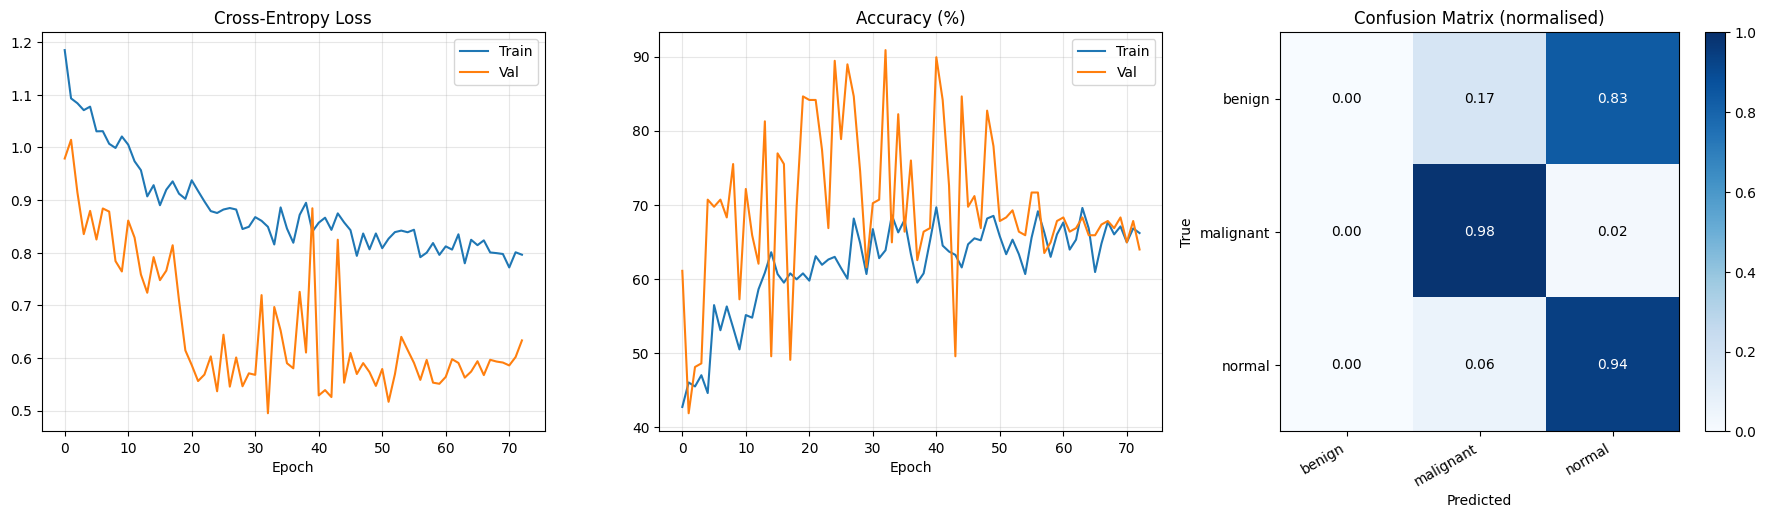

Saved to MyDrive/Lung Cancer/cgformer_results.png


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(history['tr_loss'], label='Train')
axes[0].plot(history['va_loss'], label='Val')
axes[0].set_title('Cross-Entropy Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(history['tr_acc'], label='Train')
axes[1].plot(history['va_acc'], label='Val')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion matrix
cm  = confusion_matrix(labels_all, preds_all, normalize='true')
im  = axes[2].imshow(cm, cmap='Blues', vmin=0, vmax=1)
axes[2].set_xticks(range(NUM_CLASSES))
axes[2].set_yticks(range(NUM_CLASSES))
axes[2].set_xticklabels(test_ds.classes, rotation=30, ha='right')
axes[2].set_yticklabels(test_ds.classes)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[2].text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                     fontsize=10,
                     color='white' if cm[i,j] > 0.5 else 'black')
axes[2].set_title('Confusion Matrix (normalised)')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Lung Cancer/cgformer_results.png', dpi=150)
plt.show()
print('Saved to MyDrive/Lung Cancer/cgformer_results.png')

## Cell 16 — Ablation Study
Replicates paper Table IX: tests component contributions.
Configs: BASE (full), 1A (no S³-Net), 2A (no SDG+BVB), 3A (Transformer replaces CGAB), 3B (no MHGConv).

In [31]:
def quick_eval_model(m, n_ep=5):
    """Train m for n_ep epochs and return test OA."""
    m = m.to(DEVICE)
    opt  = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=WD)
    sc   = GradScaler()
    crit = nn.CrossEntropyLoss(weight=class_weights)
    for _ in range(n_ep):
        m.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with autocast():
                loss = crit(m(imgs), labels)
            sc.scale(loss).backward(); sc.step(opt); sc.update()
    m.eval(); c = t = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            with autocast():
                logits = m(imgs.to(DEVICE))
            c += (logits.argmax(1).cpu() == labels).sum().item()
            t += labels.size(0)
    del m; torch.cuda.empty_cache()
    return 100.0 * c / t


# ── Ablation variant 1A: No S³-Net (raw input patch → CGAM) ─────────────────
class NoS3Net(CentralGraphFormer):
    """Config 1A: remove spectral processing module entirely."""
    def __init__(self):
        super().__init__()
        # Replace with identity mapping to same output shape via conv
        self.spec_module = nn.Sequential(
            nn.Conv2d(IN_CHANNELS, S3_OUT_CH, 1, bias=False),
            nn.BatchNorm2d(S3_OUT_CH), nn.ReLU()
        )
    def forward(self, x):
        Fspec  = self.spec_module(x)
        M_spa  = self.spat_module(Fspec)
        Fmod   = Fspec * M_spa
        B,C,P,_ = Fmod.shape
        z0 = Fmod.flatten(2).transpose(1,2)[:, self.ic, :]
        T  = Fmod.flatten(2).transpose(1,2)
        T, cfs = self.cgam(T, M_spa)
        z_concat = torch.cat([z0]+cfs, dim=-1)
        return self.head(self.fusion(z_concat))


# ── Ablation variant 2A: No SDG+BVB (uniform M_spa = 1) ────────────────────
class NoSpatialModule(CentralGraphFormer):
    """Config 2A: remove spatial processing — uniform relevance map."""
    def forward(self, x):
        Fspec = self.spec_module(x)
        B,C,P,_ = Fspec.shape
        M_spa = torch.ones(B,1,P,P, device=x.device, dtype=x.dtype)
        Fmod  = Fspec * M_spa
        z0 = Fmod.flatten(2).transpose(1,2)[:, self.ic, :]
        T  = Fmod.flatten(2).transpose(1,2)
        T, cfs = self.cgam(T, M_spa)
        return self.head(self.fusion(torch.cat([z0]+cfs, dim=-1)))


print('Running ablation (5 epochs each — set n_ep=200 for full comparison)...')
ablation = {}
ablation['1A: No S³-Net']         = quick_eval_model(NoS3Net())
ablation['2A: No SDG+BVB']        = quick_eval_model(NoSpatialModule())

# Full trained model (already done)
model.eval(); c=t=0
with torch.no_grad():
    for imgs, labels in test_loader:
        with autocast(): logits = model(imgs.to(DEVICE))
        c += (logits.argmax(1).cpu()==labels).sum().item(); t += labels.size(0)
ablation['BASE (Full Model)'] = 100.0*c/t

print('\n=== Ablation Results (OA %) ===')
for name, acc in ablation.items():
    bar = '█' * int(acc / 2)
    print(f'  {name:<28}: {acc:5.2f}%  {bar}')

Running ablation (5 epochs each — set n_ep=200 for full comparison)...

=== Ablation Results (OA %) ===
  1A: No S³-Net               : 82.21%  █████████████████████████████████████████
  2A: No SDG+BVB              : 57.21%  ████████████████████████████
  BASE (Full Model)           : 90.87%  █████████████████████████████████████████████


## Cell 17 — Parameter Sensitivity: Patch Size & Heads
Replicates paper Section IV-E (Tables X, XI, Fig.10, Fig.11).

Patch size sensitivity analysis (3 epochs each)...
  Patch 7×7: 54.33%
  Patch 9×9: 52.40%
  Patch 11×11: 46.15%
  Patch 13×13: 49.52%
  Patch 15×15: 61.54%


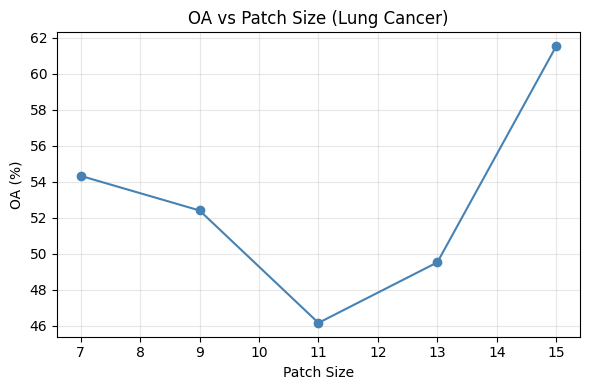

In [32]:
print('Patch size sensitivity analysis (3 epochs each)...')
patch_results = {}
for ps in [7, 9, 11, 13, 15]:
    # Rebuild dataset with different patch size
    class PatchDS(LungCancerDataset):
        def __init__(self, root, aug=False, p=ps):
            super().__init__(root, augment=aug)
            self.half = p // 2
            self._ps  = p
        def __getitem__(self, idx):
            path, label = self.samples[idx]
            img = Image.open(path).convert('RGB')
            tensor = self.tf(img)
            _, H, W = tensor.shape
            cy, cx = H//2, W//2
            y1 = max(0, cy-self.half); y2 = y1+self._ps
            x1 = max(0, cx-self.half); x2 = x1+self._ps
            patch = tensor[:, y1:y2, x1:x2]
            if patch.shape[1]<self._ps or patch.shape[2]<self._ps:
                patch = F.pad(patch,(0,self._ps-patch.shape[2],0,self._ps-patch.shape[1]))
            return patch, label

    ds_tr = PatchDS(LOCAL_TRAIN, aug=True, p=ps)
    ds_te = PatchDS(LOCAL_TEST,  aug=False, p=ps)
    ld_tr = DataLoader(ds_tr, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
    ld_te = DataLoader(ds_te, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

    m = CentralGraphFormer(patch_size=ps).to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=WD)
    sc  = GradScaler()
    crit = nn.CrossEntropyLoss(weight=class_weights)
    for _ in range(3):
        m.train()
        for imgs, labels in ld_tr:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with autocast(): loss = crit(m(imgs), labels)
            sc.scale(loss).backward(); sc.step(opt); sc.update()
    m.eval(); c=t=0
    with torch.no_grad():
        for imgs, labels in ld_te:
            with autocast(): logits = m(imgs.to(DEVICE))
            c += (logits.argmax(1).cpu()==labels).sum().item(); t += labels.size(0)
    patch_results[ps] = 100.0*c/t
    del m; torch.cuda.empty_cache()
    print(f'  Patch {ps}×{ps}: {patch_results[ps]:.2f}%')

# Plot
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(list(patch_results.keys()), list(patch_results.values()), 'o-', color='steelblue')
ax.set_xlabel('Patch Size'); ax.set_ylabel('OA (%)')
ax.set_title('OA vs Patch Size (Lung Cancer)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Cell 18 — Single Image Inference

Inference on: /tmp/LungCancer/test/benign/Bengin case (7).jpg


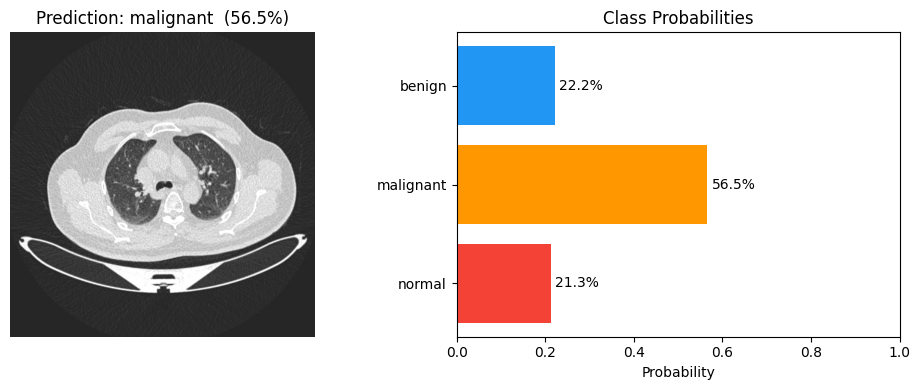

In [33]:
def predict_single(img_path, model, device, classes,
                   patch_size=PATCH_SIZE, img_size=IMG_SIZE):
    model.eval()
    half = patch_size // 2
    img  = Image.open(img_path).convert('RGB')

    tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    tensor = tf(img)
    _, H, W = tensor.shape
    cy, cx  = H//2, W//2
    y1 = max(0, cy-half); y2 = y1+patch_size
    x1 = max(0, cx-half); x2 = x1+patch_size
    patch = tensor[:, y1:y2, x1:x2].unsqueeze(0).to(device)

    with torch.no_grad(), autocast():
        logits = model(patch)
    probs = F.softmax(logits.float(), dim=1).squeeze().cpu().numpy()
    pred  = probs.argmax()

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
    a1.imshow(img, cmap='gray')
    a1.set_title(f'Prediction: {classes[pred]}  ({probs[pred]*100:.1f}%)', fontsize=12)
    a1.axis('off')
    colors = ['#2196F3','#FF9800','#F44336']
    bars = a2.barh(classes, probs,
                   color=[colors[i] for i in range(len(classes))])
    a2.set_xlabel('Probability'); a2.invert_yaxis()
    a2.set_xlim(0, 1)
    for bar, p in zip(bars, probs):
        a2.text(p + 0.01, bar.get_y() + bar.get_height()/2,
                f'{p*100:.1f}%', va='center', fontsize=10)
    a2.set_title('Class Probabilities')
    plt.tight_layout(); plt.show()


# Run on first test image
ex_cls = test_ds.classes[0]
ex_dir = os.path.join(LOCAL_TEST, ex_cls)
ex_img = os.path.join(ex_dir, os.listdir(ex_dir)[0])
print(f'Inference on: {ex_img}')
predict_single(ex_img, model, DEVICE, test_ds.classes)